# Semana 9 · Backbone 3D, atención y detección por corte

**Qué hay en este notebook:** el entregable de la semana 9: backbone, CBAM, cabeza de detección y overfit intencional como prueba de correctitud. El entrenamiento completo es de la semana 10. El notebook **no entrena**: lee lo que guarda `src/models/model3d.py` en `results/detection/`. Todos los parámetros están en `src/config.py`.

**El modelo en una frase:** cada CT se lleva a un cubo isótropo de 400 mm (256³ vóxeles de 1,5625 mm). Un **backbone FundidoraPC 3D** procesa el cubo completo, con **CBAM 3D + γ** en los dos últimos bloques del encoder y un decoder U-Net 3D hasta P3 y P2. La **detección es 2D por corte**: para cada corte axial, coronal o sagital se toman P3 y P2 en esa posición y una **cabeza con anclas por vista** (como la RPN del taller 3, con CBAM + γ) predice las cajas.

**γ (gamma):** cada capa con atención calcula `y = x + γ · CBAM(x)`. γ empieza en 0 (la atención no aporta) y la red lo aprende. Si al final γ queda cerca de 0, la red no usó esa atención.

Comandos (desde la raíz del proyecto):

```bash
uv run python -m src.models.detection cache          # cubo de los 100 casos (una vez)
uv run python -m src.models.model3d bench            # memoria y tiempo de un paso
uv run python -m src.models.model3d overfit          # prueba de correctitud
```


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib import patches
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src import config
from src.dataset import preprocessing as pre
from src.models import detection as D

plt.rcParams["figure.dpi"] = 110
D.seed_everything()
DEVICE = D.get_device()
from src.models import model3d as M3


def read_json(path):
    return json.loads(Path(path).read_text()) if Path(path).exists() else None


print("Dispositivo:", DEVICE)


Dispositivo: mps


## 1. Datos: el cubo y las tres vistas

`src/dataset/preprocessing.py`: reorientación a LPS → cubo de 400 mm con vóxel isótropo (remuestreo + relleno con aire) → ventana HU 50-1300 → [0, 1]. Como el vóxel es igual en los tres ejes, las tres vistas conservan las proporciones reales y la anisotropía del escáner deja de importar. El cubo se centra en el campo de visión (x, y) y en los cortes con hueso (z), usando solo los HU, así que funciona igual en inferencia.

Las cajas reales salen de la máscara de cada corte (una por región presente, al menos `MIN_REGION_PX` píxeles). En la vista sagital los dos coxales se ven iguales, así que se predice una sola clase "coxal" y el lado se asigna por la posición del corte (como QuickNAT con los hemisferios). La red 3D recibe el cubo completo; las vistas solo se usan para la detección 2D por corte.

In [2]:
index = D.load_index()
cases = pd.read_csv(config.CACHE_DIR / "cases.csv", dtype={"case_id": str})
print(f"Cubo: {config.CUBE_MM:.0f} mm, {config.INPUT_SIZE}³ vóxeles de {config.VOXEL_MM:.4f} mm | "
      f"hueso etiquetado fuera del cubo: {int((cases.bone_outside_frac > 0).sum())} casos")
tabla = (index.assign(con_regiones=index.positive, sin_regiones_con_hueso=~index.positive & index.bone)
         .groupby(["split", "view"])[["con_regiones", "sin_regiones_con_hueso"]].sum())
tabla["cortes"] = index.groupby(["split", "view"]).size()
tabla.reindex(["train", "val", "test"], level=0)

Cubo: 400 mm, 256³ vóxeles de 1.5625 mm | hueso etiquetado fuera del cubo: 0 casos


con_regiones  sin_regiones_con_hueso  cortes
split view                                                  
train axial             9471                    3163   17920
      coronal           7034                    1441   17920
      sagittal         12382                    1230   17920
val   axial             2055                     645    3840
      coronal           1476                     261    3840
      sagittal          2694                     210    3840
test  axial             2046                     678    3840
      coronal           1487                     362    3840
      sagittal          2653                     331    3840

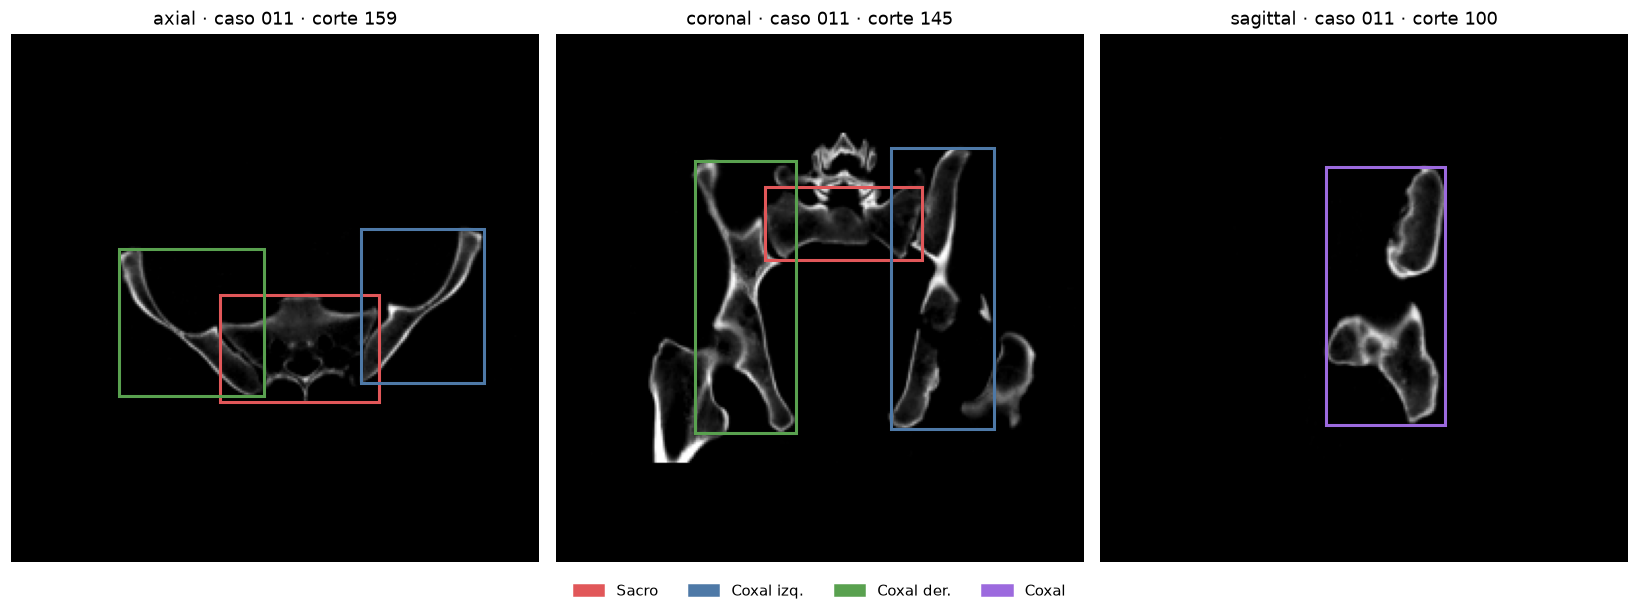

In [3]:
cid = sorted(index[index.split == "val"].case_id.unique())[0]
img = np.load(config.CACHE_DIR / f"{cid}_img.npy", mmap_mode="r")
msk = np.load(config.CACHE_DIR / f"{cid}_msk.npy", mmap_mode="r")
fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
for ax, v in zip(axes, D.VIEWS):
    d = index[(index.case_id == cid) & (index.view == v)]
    s = int(d.loc[d[D.PX_COLS].sum(axis=1).idxmax(), "slice"])
    ax.imshow(pre.view_slices(img, v, s), cmap="gray", vmin=0, vmax=255)
    m = torch.from_numpy(D.VIEW_LUT[v][pre.view_slices(msk, v, s)])[None]
    boxes, valid = D.region_boxes(m, len(D.CLASSES[v]))
    for c, name in enumerate(D.CLASSES[v]):
        if valid[0, c]:
            x0, y0, x1, y1 = boxes[0, c].tolist()
            ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=config.REGION_COLORS[name], lw=2))
    ax.set_title(f"{v} · caso {cid} · corte {s}"); ax.axis("off")
fig.legend([patches.Patch(color=config.REGION_COLORS[r]) for r in ("sacrum", "left_hipbone", "right_hipbone", "hipbone")],
           [config.REGION_LABELS[r] for r in ("sacrum", "left_hipbone", "right_hipbone", "hipbone")], loc="lower center", ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

## 2. Arquitectura

| Parte | Qué hace |
|---|---|
| Entrada | El cubo completo: 1 × 256 × 256 × 256 (un CT por paso). |
| Encoder FundidoraPC 3D | 4 bloques Conv3d 3×3×3 + InstanceNorm + ReLU + MaxPool3d: 16 → 32 → 64 → 128 canales (1/2 … 1/16). InstanceNorm porque el batch es de un solo volumen. |
| CBAM 3D + γ | Solo después de los bloques 3 y 4. Canal: avg/max-pool global → MLP; espacial: media y máximo entre canales → Conv3d 7×7×7. `y = x + γ·CBAM(x)`, γ empieza en 0. |
| Cuello de botella | 2 Conv3d dilatadas (d = 2, 4), 256 canales. |
| Decoder U-Net 3D | Conv 1×1×1 + subida trilineal + skips: P3 (64 canales, 1/8) y P2 (32 canales, 1/4). |
| Detección 2D por corte | P3 y P2 se cortan en la posición del corte (interpolación entre los dos cortes vecinos del mapa), se llevan a 32 × 32 y se concatenan (96 canales). |
| Cabeza con anclas | Una por vista: Conv3×3 → CBAM + γ → por ancla, un logit por clase y 4 offsets. NMS propio. |
| Memoria | Gradient checkpointing en los niveles de alta resolución para caber en una GPU de 6 GB. |


In [4]:
m3 = M3.Fundidora3DDetector(True)
enc = sum(D.count_params(x) for x in (m3.blocks, m3.attn, m3.neck, m3.up3, m3.up2))
pd.DataFrame([{"backbone 3D": enc, **{f"cabeza {v}": D.count_params(h) for v, h in m3.heads.items()},
               "atención (CBAM + γ)": sum(D.count_params(a) for a in m3.attn) + sum(D.count_params(h.attn) for h in m3.heads.values()),
               "total": D.count_params(m3), "capas con γ": ", ".join(m3.gammas())}], index=["modelo 3D"])


,backbone 3D,cabeza axial,cabeza coronal,cabeza sagittal,atención (CBAM + γ),total,capas con γ
modelo 3D,3386792,123187,123187,122026,19732,3755192,"enc3, enc4, head_axial, head_coronal, head_sag..."


## 3. Anclas por vista

Cada vista tiene sus anclas (9 por celda de p3: 3 escalas × 3 proporciones). Escalas = p25 / p50 / p75 de la raíz del área de las cajas de train de esa vista; proporciones ancho/alto = p20 / p50 / p80 (comando `anchors`). La cobertura es el IoU entre cada caja real de validación y su mejor ancla: si es alto, las anclas se parecen a las cajas reales.

In [5]:
filas = []
for v in D.VIEWS:
    a = config.ANCHORS[v]
    anclas = torch.tensor(D.generar_anclas_grilla(config.INPUT_SIZE // config.STRIDE, config.STRIDE, a["scales"], a["ratios"]),
                          dtype=torch.float32)
    d = index[(index.split == "val") & (index.view == v) & index.positive].sample(300, random_state=config.SEED)
    best = []
    for cid_, g in d.groupby("case_id"):
        mk = np.load(config.CACHE_DIR / f"{cid_}_msk.npy", mmap_mode="r")
        b, ok = D.region_boxes(torch.from_numpy(D.VIEW_LUT[v][pre.view_slices(mk, v, g["slice"].tolist())]), len(D.CLASSES[v]))
        best += D.box_iou(b[ok], anclas).max(1).values.tolist()
    best = np.array(best)
    filas.append({"vista": v, "escalas (px)": a["scales"], "proporciones": a["ratios"], "anclas": len(anclas),
                  "IoU mejor ancla (mediana)": round(float(np.median(best)), 2), "% cajas con IoU ≥ 0,5": round(100 * float((best >= 0.5).mean()), 1)})
pd.DataFrame(filas).set_index("vista")

,escalas (px),proporciones,anclas,IoU mejor ancla (mediana),"% cajas con IoU ≥ 0,5"
vista,,,,,
axial,"(34, 46, 58)","(0.63, 0.86, 1.58)",9216,0.76,83.6
coronal,"(39, 60, 85)","(0.36, 0.68, 1.3)",9216,0.74,81.8
sagittal,"(35, 52, 71)","(0.52, 0.74, 1.03)",9216,0.74,83.4


## 4. NMS propio frente a torchvision

El NMS (`D.nms`) está escrito a mano. Se compara con `torchvision.ops.nms` en 600 casos aleatorios: deben conservar exactamente las mismas cajas.

In [6]:
from torchvision.ops import nms as tv_nms
g = torch.Generator().manual_seed(config.SEED)
iguales = 0
for _ in range(600):
    n = int(torch.randint(1, 60, (1,), generator=g))
    xy = torch.rand(n, 2, generator=g) * 200
    wh = torch.rand(n, 2, generator=g) * 60 + 4
    b, s = torch.cat([xy, xy + wh], 1), torch.rand(n, generator=g)
    iguales += torch.equal(D.nms(b, s, 0.5), tv_nms(b, s, 0.5))
print(f"NMS propio = torchvision en {iguales} / 600 pruebas")

NMS propio = torchvision en 600 / 600 pruebas


## 5. Overfit intencional

Prueba de correctitud: 2 CT de train sin aumento, 300 iteraciones (un CT por paso). Se evalúa sobre esos mismos CT, 1 de cada 2 cortes por vista. Si el modelo, la asignación de anclas, la pérdida, la decodificación y el NMS están bien, la pérdida baja y las cajas calzan.


In [7]:
om3 = read_json(config.DETECTION_DIR / f"overfit_{config.M3D_RUN_CBAM}" / "metrics.json")
if om3 is None:
    print("Falta la prueba de overfit: uv run python -m src.models.model3d overfit")
else:
    display(pd.DataFrame({v: {k: om3[f"val_{k}_{v}"] for k in ("cls", "box", "mAP50", "mAP50_95", "mIoU", "macro_f1", "macro_auc")}
                          for v in D.VIEWS}).T.round(3))


,cls,box,mAP50,mAP50_95,mIoU,macro_f1,macro_auc
axial,0.008,0.003,0.661,0.274,0.598,0.962,0.999
coronal,0.007,0.002,0.749,0.317,0.591,0.939,0.996
sagittal,0.009,0.004,0.758,0.292,0.604,0.987,1.000
